In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd



import csv
import gzip
import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context


# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}
import helper_functions


/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# --- INIT ---

# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder


# regular clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_2' % head_folder


# # subclusters
# clustering_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/%s/scvi_res/clustering/res_%s/subclustering/res_%s' % (head_folder,hvg_to_use,cluster_resolution,subcluster_resolution)
# cluster_df_fileout = '%s/smc_subclusters.tsv' % (clustering_folder)
# folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_2' % head_folder
# folder_out = '%s/SMC_subcluster' % folder_out




# settings
log10_bf_thresh = 2
frac_circadian_samples_crossing_zero_thresh = 0.1
num_waveform_samples = 300
use_log_prop_fft = True






In [3]:
# --- LOAD THE ADATA ---

import anndata
adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- LOAD THE UNIQUE CLUSTERS ---

cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
# clusters = list(filter(lambda x: ~np.isnan(x),cluster_df['smc_subcluster'])) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(filter(lambda x: ~np.isnan(x),cluster_df['leiden_scvi_cluster'])) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(list(np.unique(clusters)))
clusters



[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [5]:
# --- MAKE THE FOLDER OUT ---

if not os.path.exists(folder_out):
    os.makedirs(folder_out)


In [6]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

# descriptions = list(adata.obs['description'].unique())
# clusters = list(adata.obs['cluster'].unique())


# regular clusters
clusters = [0, 1, 2, 3]
cluster_cell_type_dict = dict(zip(clusters,['SMC','Fibroblast','Endothelial', 'Macrophage']))


# SMC subclusters
# # clusters = sorted(list(adata.obs['cluster'].unique()))
# cluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
# cluster_cell_type_dict = dict(zip(clusters,
#                                   cluster_cell_type_names))


descriptions = ['male aligned bmal1-ko', 
                'male misaligned bmal1-control', 
                'female aligned bmal1-ko', 
                'female misaligned bmal1-control', 
                'male aligned bmal1-control', 
                'female aligned bmal1-control']

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)





Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3]


In [7]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder
if not os.path.exists(reg_head_folder):
    os.makedirs(reg_head_folder)


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    if not os.path.exists(cluster_reg_folder):
        os.makedirs(cluster_reg_folder)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)
        if not os.path.exists(cluster_description_reg_folder):
            os.makedirs(cluster_description_reg_folder)
            
        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [8]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)



22193

In [9]:
# --- SET DESCRIPTION TO male aligned bmal1-control ---

description = 'male aligned bmal1-control'


In [26]:
# --- GET THE METRIC DF'S FOR EACH CLUSTER ---

cluster_metric_dfs = []
for cluster in clusters:
    
    
    # ** load metric df **
    metric_path = '%s/de_novo_metrics.tsv' % cluster_description_folder_out_dict[cluster][description]
    metric_df = pd.read_table(metric_path,index_col='gene',sep='\t')
    
    # ** load gene parameters **
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_beta_path = '%s/gene_log_beta.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_min_max_path = '%s/log_min_max.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    
    # ** compute the expected waveforms **
    gene_expected_beta = np.array((np.exp(gene_log_alpha_df) / (np.exp(gene_log_alpha_df) + np.exp(gene_log_beta_df))))
    gene_log_min = np.array(gene_log_min_max_df['log_min']).reshape(-1,1)
    gene_log_max = np.array(gene_log_min_max_df['log_max']).reshape(-1,1)
    gene_expected_log_prop = (gene_expected_beta * (gene_log_max - gene_log_min)) + gene_log_min
    
    # ** compute the gene mesors **
    gene_expected_mesor = np.mean(gene_expected_log_prop,axis=1)
    metric_df['expected_mesor'] = gene_expected_mesor
    
    # ** compute the expected acrophases and amplitudes **
    num_grid_points = 4
    fft_res = np.fft.fft(gene_expected_log_prop,axis=1)
    freqs = np.fft.fftfreq(num_grid_points,d=24.0/num_grid_points)
    periods = 1 / freqs
    amps = abs(fft_res)
    circadian_index = np.where(np.isin(periods,[24]))[0]
    expected_acrophase = (np.arctan2(fft_res[:,circadian_index].imag,fft_res[:,circadian_index].real) % (2 * np.pi)).flatten()
    expected_acrophase = ((2 * np.pi) - expected_acrophase) % (2*np.pi)
    expected_amp = amps[:,circadian_index,].flatten()
    metric_df['expected_acrophase'] = expected_acrophase
    metric_df['expected_amp'] = expected_amp
    
    # ** add **
    cluster_metric_dfs.append(metric_df)
    


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/1791642429.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/1791642429.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/1791642429.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/1791642429.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs


In [27]:
# --- CALL CYCLERS IN EACH CELL TYPE AND GET METRIC DF FOR THEM ---

cluster_cycler_metric_dfs = []
for metric_df in cluster_metric_dfs:
    # cycler_metric_df = metric_df[metric_df['waveform_over_circadian_component_subtracted_log10_bf'] >= log10_bf_thresh]
    cycler_metric_df = metric_df[metric_df['frac_circadian_samples_crossing_zero'] <= frac_circadian_samples_crossing_zero_thresh]

    cluster_cycler_metric_dfs.append(cycler_metric_df)
    
    
    


In [28]:
# --- LOAD THE BULK JTK RESULTS ---

# load bulk results (just probe names)
bulk_jtk_res_path = '/Users/mingyaolab/Dropbox/aorta_circadian_data/bulk_data/JTKresult_Aor.MetaCycle_input.txt'
jtk_df = pd.read_table(bulk_jtk_res_path,sep='\t')

# get the gene symbols associated w/ each probe
probe_symbol_map_path = '/Users/mingyaolab/Dropbox/aorta_circadian_data/bulk_data/BHTC_probe-to-gene-mapping.txt'
probe_symbol_map_df = pd.read_table(probe_symbol_map_path,sep='\t')
probe_symbol_map = dict(zip(list(probe_symbol_map_df['probeset_IDs']), list(probe_symbol_map_df['geneSymbol'])))
gene_symbols = list(map(lambda x: "None" if x not in probe_symbol_map else probe_symbol_map[x], jtk_df['CycID']))
jtk_df['gene_symbol'] = gene_symbols

# drop symbols that have duplicates entries (i.e. multiple probes)
jtk_df = jtk_df.drop_duplicates(subset=["gene_symbol"], keep=False)

# alternatively just keep the first probe for genes
# jtk_df.drop_duplicates(subset=["gene_symbol"], keep='first')

# set gene symbol as the index
jtk_df = jtk_df.set_index('gene_symbol')

jtk_df





,CycID,BH.Q,ADJ.P,PER,LAG,AMP
gene_symbol,,,,,,
Lypla1,10344624,1.0,0.936661,24,2,57.629203
Atp6v1h,10344637,1.0,1.000000,24,18,6.664481
Oprk1,10344653,1.0,1.000000,24,2,0.989949
Rb1cc1,10344658,1.0,1.000000,24,14,12.232947
Alkal1,10344674,1.0,1.000000,24,14,0.601041
...,...,...,...,...,...,...
Gm20873,10608420,1.0,1.000000,24,6,25.226034
4932431L22Rik,10608438,1.0,0.792928,24,2,2.899138
Gm20772,10608460,1.0,1.000000,24,4,23.652722


In [29]:
# --- ADJUST THE ACROPHASES FOR BMAL1 TO BE THE START ---

jtk_df['ADJ_LAG'] = (jtk_df['LAG'] - jtk_df.loc['Arntl']['LAG']) % (24)
jtk_df['ADJ_LAG']


gene_symbol
Lypla1           20.0
Atp6v1h          12.0
Oprk1            20.0
Rb1cc1            8.0
Alkal1            8.0
                 ... 
Gm20873           0.0
4932431L22Rik    20.0
Gm20772          22.0
Rbm31y           20.0
Gm20826          18.0
Name: ADJ_LAG, Length: 19065, dtype: float64

In [30]:
# --- LIMIT JTK DF TO ONLY THE SIGNIFICANT CYCLERS ---

jtk_df = jtk_df[jtk_df['BH.Q'] <= 0.05]
jtk_df



,CycID,BH.Q,ADJ.P,PER,LAG,AMP,ADJ_LAG
gene_symbol,,,,,,,
Gsta3,10345065,0.005530,4.739881e-05,24,0,106.985256,18.0
Npas2,10345675,0.000002,6.554591e-10,24,6,268.735932,0.0
Coq10b,10346298,0.001825,9.206542e-06,24,17,106.543314,11.0
Dgkd,10348321,0.023927,4.661292e-04,24,14,75.342228,8.0
Slc41a1,10349711,0.043974,1.280522e-03,24,13,67.846896,7.0
...,...,...,...,...,...,...,...
Hdac6,10603387,0.002906,1.811928e-05,24,13,23.316846,7.0
Mospd1,10604630,0.037304,1.002148e-03,24,12,78.771695,6.0
Las1l,10605831,0.023927,4.661292e-04,24,13,23.917887,7.0


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/439810074.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cycler_df['expected_acrophase_hours'] = (cycler_df['expected_acrophase'] / np.pi) * 12.0
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/439810074.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cycler_df['expected_acrophase_hours_bmal1_adj'] = (cycler_df['expected_acrophase_hours'] - cycler_df['expected_acrophase_hours'].loc['Arntl']) % (24.0)


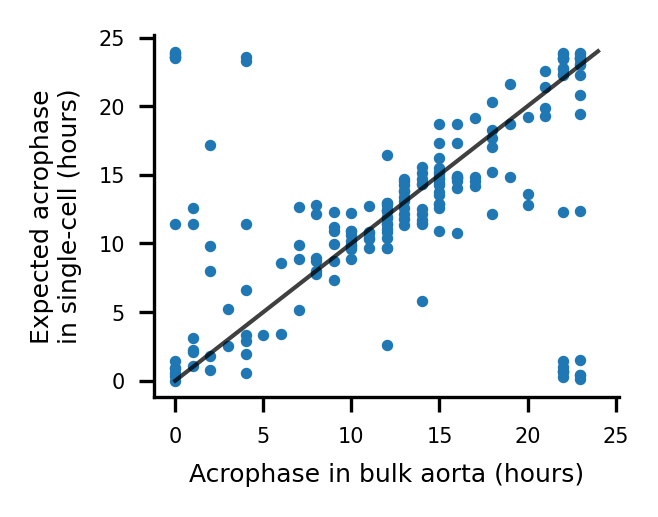

In [49]:
# --- VIZ THE CORRESPONDENCE BETWEEN ACROPHASES FOR SMC'S ---

cycler_df = cluster_cycler_metric_dfs[0]

# get the expected acrophase in hours
cycler_df['expected_acrophase_hours'] = (cycler_df['expected_acrophase'] / np.pi) * 12.0
cycler_df['expected_acrophase_hours_bmal1_adj'] = (cycler_df['expected_acrophase_hours'] - cycler_df['expected_acrophase_hours'].loc['Arntl']) % (24.0)


inter_genes = list(set(cycler_df.index).intersection(set(jtk_df.index)))

fig,ax = plt.subplots(figsize=(2,1.6), dpi=300)
plt.scatter(jtk_df.loc[inter_genes]['ADJ_LAG'], cycler_df.loc[inter_genes]['expected_acrophase_hours_bmal1_adj'],s=3)
plt.plot(np.linspace(0,24,100),np.linspace(0,24,100),c='k',alpha=0.75)
plt.xlabel("Acrophase in bulk aorta (hours)")
plt.ylabel("Expected acrophase\nin single-cell (hours)")
sns.despine()
plt.show()



In [59]:
# --- LOAD THE BULK JTK RESULTS FOR MACROPHAGES ---

# load bulk results (just probe names)
bulk_jtk_res_path = '/Users/mingyaolab/Dropbox/aorta_circadian_data/bulk_data/macrophage.csv'
jtk_df = pd.read_table(bulk_jtk_res_path,sep=',')

# drop symbols that have duplicates entries (i.e. multiple probes)
jtk_df = jtk_df.drop_duplicates(subset=["Symbol"], keep=False)

# alternatively just keep the first probe for genes
# jtk_df.drop_duplicates(subset=["gene_symbol"], keep='first')

# set gene symbol as the index
jtk_df = jtk_df.set_index('Symbol')

jtk_df


# --- ADJUST THE ACROPHASES FOR BMAL1 TO BE THE START ---

jtk_df['ADJ_LAG'] = (jtk_df['JTKphase'] - jtk_df.loc['Arntl']['JTKphase']) % (24)
jtk_df['ADJ_LAG']


# --- LIMIT JTK DF TO ONLY THE SIGNIFICANT CYCLERS ---

jtk_df = jtk_df[jtk_df['JTKQ'] <= 0.1]
jtk_df






,Probeset_ID,Time,Values,JTKP,JTKQ,JTKperiod,JTKphase,Tissue,ADJ_LAG
Symbol,,,,,,,,,
Dis3l2,10348096,0;4;8;12;16;20;24;28;32;36;40;44,365.7;391.8;417.1;385.6;340.1;268.7;383.7;408....,0.000032,0.059729,24.0,8.0,macrophages,6.0
Phf15,10385747,0;4;8;12;16;20;24;28;32;36;40;44,500.7;509.5;660.8;1056.0;702.3;513.7;487.2;573...,0.000032,0.059729,24.0,14.0,macrophages,12.0
Nr1d1,10390691,0;4;8;12;16;20;24;28;32;36;40;44,118.1;353.1;1978.1;1791.4;401.3;139.8;140.7;44...,0.000002,0.059729,24.0,10.0,macrophages,8.0
Ahsa1,10397518,0;4;8;12;16;20;24;28;32;36;40;44,2410.7;1911.5;1679.6;2329.2;2730.2;3029.4;2177...,0.000032,0.059729,24.0,20.0,macrophages,18.0
Nr1d2,10417734,0;4;8;12;16;20;24;28;32;36;40;44,135.9;407.7;932.2;1124.4;760.6;274.2;167.7;363...,0.000009,0.059729,24.0,12.0,macrophages,10.0
...,...,...,...,...,...,...,...,...,...
Mir501,10603304,0;4;8;12;16;20;24;28;32;36;40;44,60.7;55.8;53.4;65.1;66.2;76.1;57.6;58.5;57.0;6...,0.000645,0.097523,24.0,20.0,macrophages,18.0
1810037I17Rik,10604019,0;4;8;12;16;20;24;28;32;36;40;44,2340.2;2362.4;2212.1;2012.4;2056.4;2089.1;2263...,0.000645,0.097523,24.0,4.0,macrophages,2.0
Rbmx,10604735,0;4;8;12;16;20;24;28;32;36;40;44,682.6;636.2;615.6;499.7;440.7;390.2;689.0;717....,0.000645,0.097523,24.0,4.0,macrophages,2.0


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_44937/3834064127.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cycler_df['expected_acrophase_hours'] = (cycler_df['expected_acrophase'] / np.pi) * 12.0


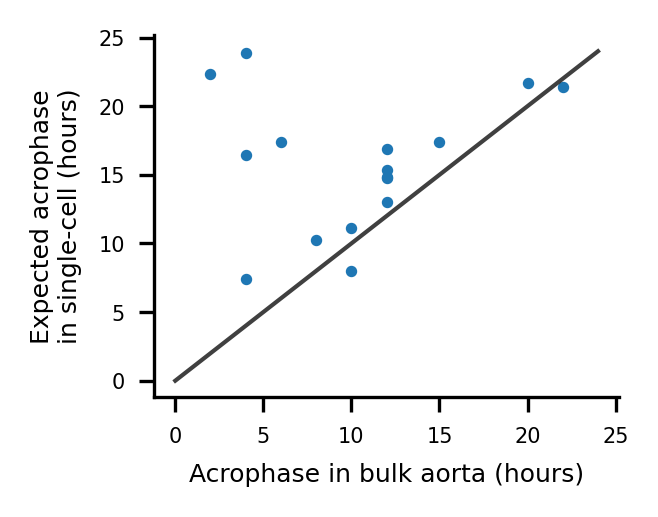

In [62]:
# --- VIZ THE CORRESPONDENCE BETWEEN ACROPHASES FOR Macrophages'S ---

cycler_df = cluster_cycler_metric_dfs[3]

# get the expected acrophase in hours
cycler_df['expected_acrophase_hours'] = (cycler_df['expected_acrophase'] / np.pi) * 12.0
# cycler_df['expected_acrophase_hours_bmal1_adj'] = (cycler_df['expected_acrophase_hours'] - cycler_df['expected_acrophase_hours'].loc['Dbp']) % (24.0)


inter_genes = list(set(cycler_df.index).intersection(set(jtk_df.index)))

fig,ax = plt.subplots(figsize=(2,1.6), dpi=300)
plt.scatter(jtk_df.loc[inter_genes]['ADJ_LAG'], cycler_df.loc[inter_genes]['expected_acrophase_hours'],s=3)
plt.plot(np.linspace(0,24,100),np.linspace(0,24,100),c='k',alpha=0.75)
plt.xlabel("Acrophase in bulk aorta (hours)")
plt.ylabel("Expected acrophase\nin single-cell (hours)")
sns.despine()
plt.show()

